In [6]:
import os
# Uncomment the following line to disable strict convolution algorithm picker for XLA (if needed)
#os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
import json, pickle, glob
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D, Concatenate, BatchNormalization, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import pandas as pd

2025-10-28 11:55:18.658481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-28 11:55:18.881346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-28 11:55:18.945977: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-28 11:55:19.428470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 11:55:21.346075: W tensorflow/compiler/tf2

In [ ]:
training_data_path= "archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"      #update with your path of the BraTS2020 training data

In [3]:
path_test = os.path.join(training_data_path, "BraTS20_Training_355/BraTS20_Training_355_flair.nii")
test_image_flair = nib.load(path_test).get_fdata()
print("Shape: ", test_image_flair.shape)
print("Dtype: ", test_image_flair.dtype)

print("Min: ", test_image_flair.min())
print("Max: ", test_image_flair.max())

Shape:  (240, 240, 155)
Dtype:  float64
Min:  0.0
Max:  1854.603271484375


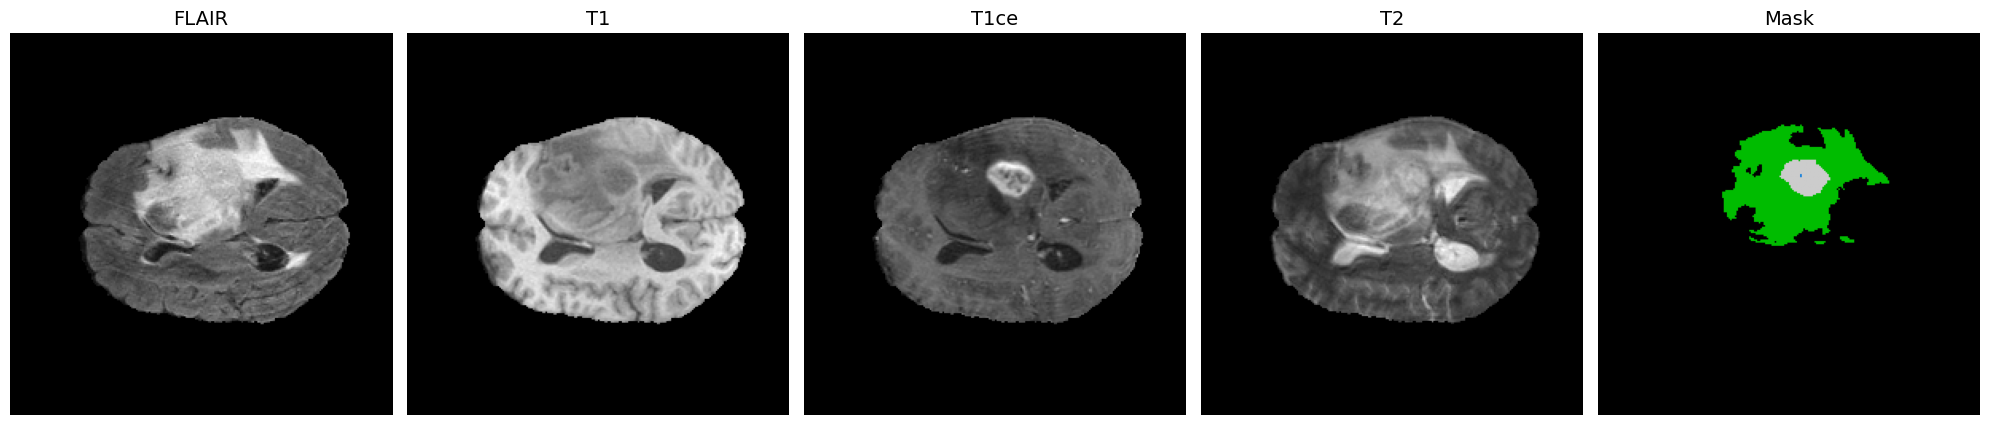

In [4]:
# Caricamento immagini per esempio di visualizzazione
test_image_flair = nib.load(training_data_path + '/BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1 = nib.load(training_data_path + '/BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce = nib.load(training_data_path + '/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2 = nib.load(training_data_path + '/BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask = nib.load(training_data_path + '/BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()

# Slice centrale
slice_idx = test_image_flair.shape[2] // 2


fig, axes = plt.subplots(1, 5, figsize=(20, 8))

images = [
    (test_image_flair[:, :, slice_idx], "FLAIR"),
    (test_image_t1[:, :, slice_idx], "T1"),
    (test_image_t1ce[:, :, slice_idx], "T1ce"),
    (test_image_t2[:, :, slice_idx], "T2"),
    (test_mask[:, :, slice_idx], "Mask")
]

for ax, (img, title) in zip(axes, images):
    ax.imshow(img, cmap="gray" if "Mask" not in title else "nipy_spectral")
    ax.set_title(title, fontsize=14)
    ax.axis("off")  

plt.tight_layout()
plt.show()


In [8]:
import os
import numpy as np
import nibabel as nib
from sklearn.preprocessing import StandardScaler
## load_patches extracts tumor-focused, normalized 3D patches from MRI volumes, 
## data_generator continuously supplies these patches to the network for efficient training.

################################################################################
def load_patches(subject_id, path, patch_size=(64,64,64), num_patches=5, num_classes=4, min_tumor_frac=0.01):
    modalities = ['flair','t1','t1ce','t2']
    images = []
    # Load the four modalities and standardize
    for mod in modalities:
        img_path = os.path.join(path, f"BraTS20_Training_{subject_id}",
                                f"BraTS20_Training_{subject_id}_{mod}.nii")
        if not os.path.exists(img_path):
            print(f"File not found: {img_path}, skipping subject {subject_id}")
            return None, None
        img = nib.load(img_path).get_fdata().astype(np.float32)
        
        img = StandardScaler().fit_transform(img.reshape(-1,1)).reshape(img.shape)
        images.append(img)
    images = np.stack(images, axis=-1)

    mask_path = os.path.join(path, f"BraTS20_Training_{subject_id}",
                             f"BraTS20_Training_{subject_id}_seg.nii")
    if not os.path.exists(mask_path):
        print(f"File not found: {mask_path}, skipping subject {subject_id}")
        return None, None
    mask = nib.load(mask_path).get_fdata().astype(np.uint8)

    # shape of the images
    H, W, D = images.shape[:3]
    px, py, pz = patch_size

    # search for tumor voxels and centres
    tumor_voxels = np.argwhere(mask > 0)
    centers = []
    if tumor_voxels.size == 0:
        # random centers if no tumor
        for _ in range(num_patches):
            cx = np.random.randint(0, H) if H > 1 else 0
            cy = np.random.randint(0, W) if W > 1 else 0
            cz = np.random.randint(0, D) if D > 1 else 0
            centers.append((cx, cy, cz))
    else:
        indices = np.random.choice(len(tumor_voxels), size=num_patches*2, replace=True)
        centers = [tuple(tumor_voxels[i]) for i in indices]

    patch_images, patch_masks = [], []
    selected = 0

    for cx, cy, cz in centers:
        if selected >= num_patches:
            break

        # central slice
        sx = cx - px//2; ex = sx + px
        sy = cy - py//2; ey = sy + py
        sz = cz - pz//2; ez = sz + pz

        # clamp source
        sx_src = max(0, sx); ex_src = min(H, ex)
        sy_src = max(0, sy); ey_src = min(W, ey)
        sz_src = max(0, sz); ez_src = min(D, ez)

        patch_img = images[sx_src:ex_src, sy_src:ey_src, sz_src:ez_src, :]
        patch_mask = mask[sx_src:ex_src, sy_src:ey_src, sz_src:ez_src]

        # calculate the padding needed
        pad_x0 = max(0, 0 - sx)
        pad_y0 = max(0, 0 - sy)
        pad_z0 = max(0, 0 - sz)
        pad_x1 = max(0, ex - H)
        pad_y1 = max(0, ey - W)
        pad_z1 = max(0, ez - D)

        if any([pad_x0,pad_x1,pad_y0,pad_y1,pad_z0,pad_z1]):
            patch_img = np.pad(patch_img, ((pad_x0,pad_x1),(pad_y0,pad_y1),(pad_z0,pad_z1),(0,0)), mode='constant', constant_values=0)
            patch_mask = np.pad(patch_mask, ((pad_x0,pad_x1),(pad_y0,pad_y1),(pad_z0,pad_z1)), mode='constant', constant_values=0)

        # if still different (extreme), do final pad
        if patch_img.shape[:3] != (px,py,pz):
            need_x = px - patch_img.shape[0]
            need_y = py - patch_img.shape[1]
            need_z = pz - patch_img.shape[2]
            if need_x < 0 or need_y < 0 or need_z < 0:
                # if patch is larger than image in any dimension, skip
                continue
            patch_img = np.pad(patch_img, ((0,need_x),(0,need_y),(0,need_z),(0,0)), mode='constant', constant_values=0)
            patch_mask = np.pad(patch_mask, ((0,need_x),(0,need_y),(0,need_z)), mode='constant', constant_values=0)

        # tumor fraction check
        tumor_frac = np.sum(patch_mask > 0) / float(np.prod(patch_mask.shape))
        if tumor_frac < min_tumor_frac:
            continue

        # one-hot
        one_hot = np.zeros(patch_mask.shape + (num_classes,), dtype=np.float32)
        for i, label in enumerate([0,1,2,4]):
            one_hot[..., i] = (patch_mask == label).astype(np.float32)

        patch_images.append(patch_img.astype(np.float32))
        patch_masks.append(one_hot)
        selected += 1

    if selected == 0:
        return None, None

    return np.array(patch_images), np.array(patch_masks)


def data_generator(subject_ids, path, batch_size, patch_size=(64,64,64), num_patches=5):
    ids = list(subject_ids)
    while True:
        np.random.shuffle(ids)
        for i in range(0, len(ids), batch_size):
            batch_ids = ids[i:i+batch_size]
            batch_images, batch_masks = [], []
            for sid in batch_ids:
                imgs, masks = load_patches(sid, path, patch_size=patch_size, num_patches=num_patches)
                if imgs is not None:
                    batch_images.append(imgs)
                    batch_masks.append(masks)
            if batch_images:
                yield np.concatenate(batch_images, axis=0), np.concatenate(batch_masks, axis=0)


In [18]:
# LOSS & METRICHE
# ========================
# Dice Loss - valuta la forma/overlap globale della segmentazione .
# Focal Loss - forza la rete a imparare i pixel difficili e le classi rare, penalizza molto se predice male il tumore
def dice_score_per_class(y_true, y_pred, epsilon=1e-6):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=[0, 1, 2, 3])
    union = tf.reduce_sum(y_true_f, axis=[0, 1, 2, 3]) + tf.reduce_sum(y_pred_f, axis=[0, 1, 2, 3])
    return (2. * intersection + epsilon) / (union + epsilon)

def dice_coefficient(y_true, y_pred, epsilon=1e-6):
    per_class = dice_score_per_class(y_true, y_pred, epsilon)
    return tf.reduce_mean(per_class[1:])   # esclude background

def weighted_dice_loss(y_true, y_pred, class_weights, epsilon=1e-6):
    per_class = dice_score_per_class(y_true, y_pred, epsilon)
    dice_wmean = tf.reduce_sum(per_class * class_weights) / tf.reduce_sum(class_weights)
    return 1.0 - dice_wmean

def focal_loss_mc(y_true, y_pred, alpha=0.25, gamma=2.0, epsilon=1e-6):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    ce = -y_true_f * tf.math.log(y_pred_f)
    weight = alpha * tf.pow(1.0 - y_pred_f, gamma)
    return tf.reduce_mean(weight * ce)

def combined_loss(y_true, y_pred,
                  class_weights=tf.constant([0.1, 2.0, 1.0, 1.5], dtype=tf.float32),
                  alpha=0.25, gamma=2.0, epsilon=1e-6):
    dice_l = weighted_dice_loss(y_true, y_pred, class_weights, epsilon)
    focal_l = focal_loss_mc(y_true, y_pred, alpha, gamma, epsilon)
    return 0.5 * dice_l + 0.5 * focal_l


#Metrics for evaluation during training
def dice_score_per_class(y_true, y_pred, epsilon=1e-6):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=[0, 1, 2, 3])
    union = tf.reduce_sum(y_true_f, axis=[0, 1, 2, 3]) + tf.reduce_sum(y_pred_f, axis=[0, 1, 2, 3])
    return (2. * intersection + epsilon) / (union + epsilon)

def dice_coef(y_true, y_pred, epsilon=1e-6):
    per_class = dice_score_per_class(y_true, y_pred, epsilon)
    return tf.reduce_mean(per_class[1:])   # media classi tumorali (esclude background)

def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    return dice_score_per_class(y_true, y_pred, epsilon)[1]

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    return dice_score_per_class(y_true, y_pred, epsilon)[2]

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    return dice_score_per_class(y_true, y_pred, epsilon)[3]

# Precision, sensitivity, specificity voxel-wise
def precision(y_true, y_pred, epsilon=1e-6):
    y_pred_f = tf.argmax(y_pred, axis=-1)
    y_true_f = tf.argmax(y_true, axis=-1)
    tp = tf.reduce_sum(tf.cast(tf.equal(y_true_f, y_pred_f) & (y_true_f > 0), tf.float32))
    fp = tf.reduce_sum(tf.cast((y_true_f == 0) & (y_pred_f > 0), tf.float32))
    return tp / (tp + fp + epsilon)

def sensitivity(y_true, y_pred, epsilon=1e-6):
    y_pred_f = tf.argmax(y_pred, axis=-1)
    y_true_f = tf.argmax(y_true, axis=-1)
    tp = tf.reduce_sum(tf.cast(tf.equal(y_true_f, y_pred_f) & (y_true_f > 0), tf.float32))
    fn = tf.reduce_sum(tf.cast((y_true_f > 0) & (y_pred_f == 0), tf.float32))
    return tp / (tp + fn + epsilon)

def specificity(y_true, y_pred, epsilon=1e-6):
    y_pred_f = tf.argmax(y_pred, axis=-1)
    y_true_f = tf.argmax(y_true, axis=-1)
    tn = tf.reduce_sum(tf.cast((y_true_f == 0) & (y_pred_f == 0), tf.float32))
    fp = tf.reduce_sum(tf.cast((y_true_f == 0) & (y_pred_f > 0), tf.float32))
    return tn / (tn + fp + epsilon)


In [28]:
# MODELLO U-NET 3D
# 16, 32, 64 filtri convoluzionali, batch normalization, ReLU, softmax output

def build_u_net(input_shape, num_classes=4):
    inputs = Input(input_shape)

    c1 = Conv3D(16, 3, padding='same')(inputs)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    c1 = Conv3D(16, 3, padding='same')(c1)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    p1 = MaxPooling3D(2)(c1)

    c2 = Conv3D(32, 3, padding='same')(p1)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    c2 = Conv3D(32, 3, padding='same')(c2)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    p2 = MaxPooling3D(2)(c2)

    c3 = Conv3D(64, 3, padding='same')(p2)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    c3 = Conv3D(64, 3, padding='same')(c3)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)

    u4 = UpSampling3D(2)(c3)
    u4 = Concatenate()([u4, c2])
    c4 = Conv3D(32, 3, padding='same')(u4)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    c4 = Conv3D(32, 3, padding='same')(c4)
    c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)

    u5 = UpSampling3D(2)(c4)
    u5 = Concatenate()([u5, c1])
    c5 = Conv3D(16, 3, padding='same')(u5)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)
    c5 = Conv3D(16, 3, padding='same')(c5)
    c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)

    outputs = Conv3D(num_classes, 1, activation='softmax')(c5)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coefficient]
    )
    return model

In [11]:
# Hyperparameters
PATCH_SIZE = (64, 64, 64)   #dimensione del patch 3D
BATCH_SIZE = 2   #aumentarlo riduce il trainging time ma richiede più memoria GPU
NUM_PATCHES_PER_SUBJECT = 5
EPOCHS = 20                         
NUM_CLASSES = 4

In [12]:
#SETUP TRAINING

# train validation test split
subject_ids = sorted([p.split('_')[-1] for p in glob.glob(os.path.join(training_data_path,'BraTS20_Training_*'))])


# Divido il dataset in 68% training, 17% validation, e 15% test
train_patients_ids, test_patients_ids = train_test_split(subject_ids, test_size=0.15, random_state=7)
train_patients_ids, validation_patients_ids = train_test_split(train_patients_ids, test_size=0.2, random_state=7) # 0.2 * 0.85 = 0.17

print(f"Numero di pazienti nel training set: {len(train_patients_ids)}")
print(f"Numero di pazienti nel validation set: {len(validation_patients_ids)}")
print(f"Numero di pazienti nel test set: {len(test_patients_ids)}")



Numero di pazienti nel training set: 250
Numero di pazienti nel validation set: 63
Numero di pazienti nel test set: 56


In [ ]:
# TRAINING

# Debug: verifica GPU
print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


model = build_u_net(input_shape=PATCH_SIZE + (4,), num_classes=NUM_CLASSES)

model_save_path = "u_net__model.keras"
callbacks = [
    ModelCheckpoint(model_save_path, save_best_only=True,
                    monitor='val_dice_coefficient', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

# Generators
train_generator = data_generator(train_patients_ids, training_data_path,
                                 batch_size=BATCH_SIZE,
                                 patch_size=PATCH_SIZE,
                                 num_patches=NUM_PATCHES_PER_SUBJECT)

validation_generator = data_generator(validation_patients_ids, training_data_path,
                                      batch_size=BATCH_SIZE,
                                      patch_size=PATCH_SIZE,
                                      num_patches=NUM_PATCHES_PER_SUBJECT)

# Sanity check shape batch
xb, yb = next(train_generator)
print("Batch images:", xb.shape, "Batch masks:", yb.shape)

# Step per epoch calculation
steps_per_epoch = max(1, len(train_patients_ids) * NUM_PATCHES_PER_SUBJECT // BATCH_SIZE)
validation_steps = max(1, len(validation_patients_ids) * NUM_PATCHES_PER_SUBJECT // BATCH_SIZE)

csvlog = CSVLogger("training_log.csv", append=True)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


# ========================
# PLOTTING
# ========================
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(); plt.title("Loss trend"); plt.show()

plt.plot(history.history['dice_coefficient'], label='Training Dice')
plt.plot(history.history['val_dice_coefficient'], label='Validation Dice')
plt.legend(); plt.title("Dice trend"); plt.show()

# saving the history in json and pickle formats
with open("training_history.pkl","wb") as f: pickle.dump(history.history, f)
with open("training_history_final_version.json", "w") as f:
    json.dump(history.history, f)



plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Combined Loss')
plt.plot(history.history['val_loss'], label='Validation Combined Loss')
plt.title("Combined Loss (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


print("History salvata in training_history.json")
print("\nAddestramento completato!")


In [29]:
# Carica il modello migliore specificando SOLO gli oggetti custom della compilazione ORIGINALE
best_model = load_model(
    "u_net__model.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient
        # NON includere le altre metriche qui, perché non erano nel modello salvato
    }
)
print("Best model caricato correttamente")

# Prepara il generatore per il test set (invariato)
test_generator = data_generator(test_patients_ids, training_data_path,
                                batch_size=BATCH_SIZE,
                                patch_size=PATCH_SIZE,
                                num_patches=NUM_PATCHES_PER_SUBJECT)

# Calcola gli step per la valutazione (invariato)
test_steps = len(test_patients_ids) * NUM_PATCHES_PER_SUBJECT // BATCH_SIZE

Best model caricato correttamente


In [ ]:
# Ricompilo il modello caricato con nuove metriche per la valutazione
print("\nRicompilazione del modello caricato per la valutazione...")
best_model.compile(
    loss="categorical_crossentropy", 
    optimizer=Adam(learning_rate=1e-4), 
    metrics=[
        "accuracy",
        tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES), 
        dice_coefficient,       
        precision,              
        sensitivity,            
        specificity,            
        dice_coef_necrotic,     
        dice_coef_edema,        
        dice_coef_enhancing     
    ]
)
print("Ricompilazione completata.")

# Valutazione sul test set usando il modello ricompilato
print("\nInizio valutazione sul test set...")
results = best_model.evaluate(test_generator, steps=test_steps, verbose=1)

# Descrizioni leggibili per le metriche
descriptions = [
    "Loss (Categorical Crossentropy)", # Nota: questa è la loss della ricompilazione
    "Accuracy",
    "MeanIoU",
    "Dice coefficient (global)",
    "Precision",
    "Sensitivity (Recall)",
    "Specificity",
    "Dice coef Necrotic (class 1)",
    "Dice coef Edema (class 2)",
    "Dice coef Enhancing (class 4)"
]

# Print results with checks
print("\nModel evaluation on the test set:")
print("===================================")
# verify lengths match
if len(descriptions) == len(results):
    for desc, value in zip(descriptions, results):
        print(f"{desc:30}: {value:.4f}")

    #  CSV Saving
    df = pd.DataFrame({"Metric": descriptions, "Value": results})
    csv_filename = "test_metrics.csv"
    df.to_csv(csv_filename, index=False)
    print(f"\nRisultati salvati in {csv_filename}")

    # JSON Saving
    results_dict = {desc: float(val) for desc, val in zip(descriptions, results)}
    json_filename = "test_metrics.json"
    with open(json_filename, "w") as f:
        json.dump(results_dict, f, indent=4)
    print(f"Risultati salvati in {json_filename}")

# else:
#     # Errore se le lunghezze non coincidono
#     print("ERRORE: Differenza tra numero di descrizioni e risultati dopo la valutazione")
#     print(f"Nomi metriche dal modello ({len(best_model.metrics_names)}): {best_model.metrics_names}")
#     print(f"Valori ottenuti ({len(results)}): {results}")
#     print(f"Descrizioni attese ({len(descriptions)}): {descriptions}")


Ricompilazione del modello caricato per la valutazione...
Ricompilazione completata.

Inizio valutazione sul test set...
140/140 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9323 - dice_coef_edema: 0.7402 - dice_coef_enhancing: 0.7886 - dice_coef_necrotic: 0.6401 - dice_coefficient: 0.7229 - loss: 0.3001 - mean_io_u_2: 0.3750 - precision: 0.9339 - sensitivity: 0.8517 - specificity: 0.9847

Model evaluation on the test set:
Loss (Categorical Crossentropy): 0.3001
Accuracy                      : 0.9323
MeanIoU                       : 0.3750
Dice coefficient (global)     : 0.7229
Precision                     : 0.9339
Sensitivity (Recall)          : 0.8517
Specificity                   : 0.9847
Dice coef Necrotic (class 1)  : 0.6401
Dice coef Edema (class 2)     : 0.7402
Dice coef Enhancing (class 4) : 0.7886

Risultati salvati in test_metrics_v2.csv
Risultati salvati in test_metrics_v2.json


In [ ]:
# Mostro una predizione di  paziente del test


# Viola = background (nessun tumore).
# Verde = edema (tumore + edema circostante).
# Giallo = tumore attivo
# Blu = necrosi o core non attivo

def plot_mask(id,test_patients_ids, training_data_path,PATCH_SIZE,num_patches, best_model):
    test_id = test_patients_ids[id]  
    print(f"Test su paziente ID: {test_id}")
    imgs, masks = load_patches(test_id, training_data_path,
                           patch_size=PATCH_SIZE,
                           num_patches=1)

    pred = best_model.predict(imgs)
    pred_class = np.argmax(pred[0], axis=-1)  # da softmax a classi
    slice_idx = PATCH_SIZE[2] // 2  # slice centrale 

    class_names = ["No Tumor (BG)","Necrotic and non-enhancing tumor", "Peritumoral edema (ED)","GD-enhancing tumor (ET)"]

    print("Viola = background (nessun tumore). \nVerde = edema (tumore + edema circostante). \nGiallo = tumore attivo \nBlu = necrosi o core non attivo")
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Input Flair")
    plt.imshow(imgs[0][:,:,slice_idx,0], cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(np.argmax(masks[0][:,:,slice_idx,:], axis=-1))
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Global Prediction")
    plt.imshow(pred_class[:,:,slice_idx])
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Predizione per classi: Giallo = parte della classe presente" )
    plt.figure(figsize=(15,5))
    for c, name in enumerate(class_names):
        plt.subplot(1,4,c+1)
        plt.title(name)
        plt.imshow(pred_class[:,:,slice_idx] == c, cmap="viridis")
        plt.axis("off")
    plt.show()

    
    plt.show()





Test su paziente ID: 340
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Viola = background (nessun tumore). 
Verde = edema (tumore + edema circostante). 
Giallo = tumore attivo 
Blu = necrosi o core non attivo


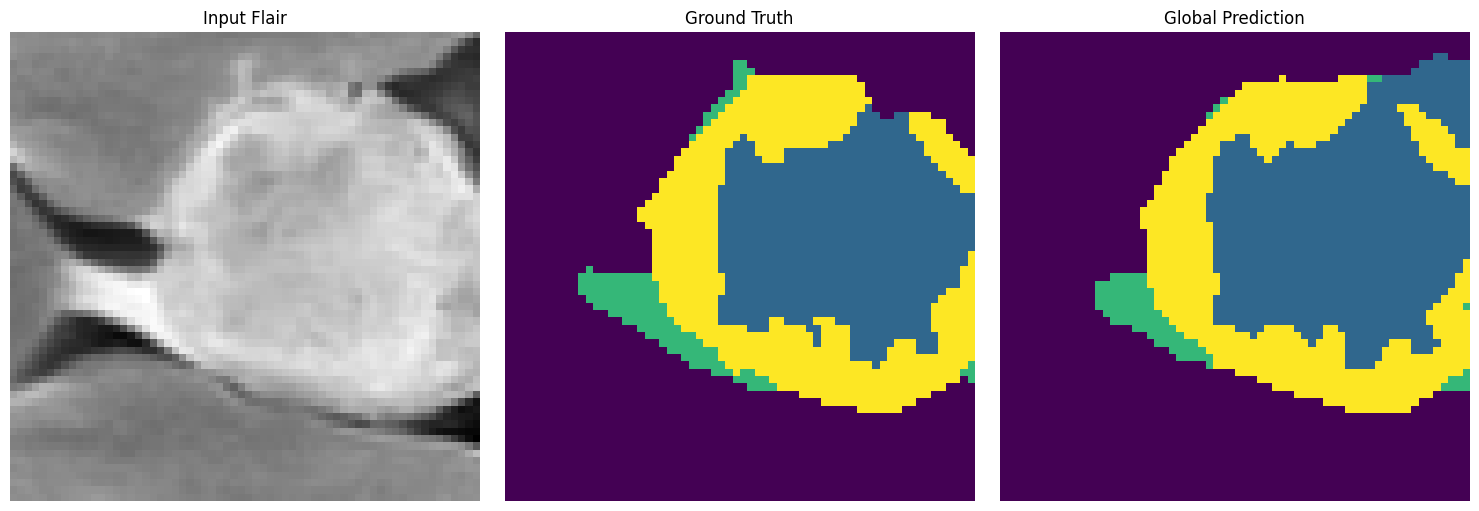

Predizione per classi: Giallo = parte della classe presente


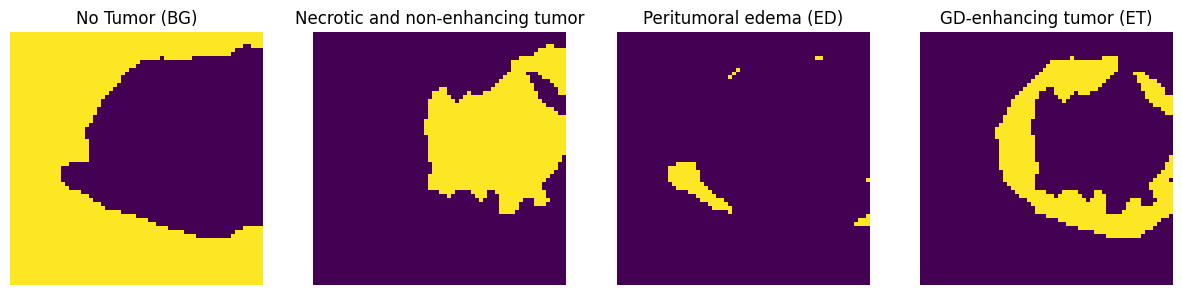

In [17]:
# for i in range(len(test_patients_ids)):
#     plot_mask(i,test_patients_ids, training_data_path,PATCH_SIZE,1, best_model)
#     print(i)

plot_mask(33,test_patients_ids, training_data_path,PATCH_SIZE,1, best_model)